In [1]:
!rm -rf diploma_centpy_parallelization_py
# Флаг -b указывает конкретную ветку
!git clone -b feature/jax-centpy https://github.com/filkinc/diploma_centpy_parallelization_py.git
%cd diploma_centpy_parallelization_py
%cd /content/diploma_centpy_parallelization_py/jax_centpy

# Установка зависимостей
!pip install centpy pandas matplotlib seaborn

Cloning into 'diploma_centpy_parallelization_py'...
remote: Enumerating objects: 473, done.
remote: Counting objects: 100% (55/55), done.
remote: Compressing objects: 100% (54/54), done.
remote: Total 473 (delta 2), reused 3 (delta 1), pack-reused 418 (from 1)
Receiving objects: 100% (473/473), 37.74 MiB | 11.56 MiB/s, done.
Resolving deltas: 100% (211/211), done.
/content/diploma_centpy_parallelization_py
/content/diploma_centpy_parallelization_py/jax_centpy


In [2]:
!git clone https://github.com/tumaer/JAXFLUIDS.git
!pip install -e JAXFLUIDS

Cloning into 'JAXFLUIDS'...
remote: Enumerating objects: 2563, done.
remote: Counting objects: 100% (689/689), done.
remote: Compressing objects: 100% (228/228), done.
remote: Total 2563 (delta 539), reused 510 (delta 461), pack-reused 1874 (from 2)
Receiving objects: 100% (2563/2563), 13.19 MiB | 19.19 MiB/s, done.
Resolving deltas: 100% (1474/1474), done.
Obtaining file:///content/diploma_centpy_parallelization_py/jax_centpy/JAXFLUIDS
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for jaxfluids (pyproject.toml) ... done
  Created wheel for jaxfluids: filename=jaxfluids-0.2.1-0.editable-py3-none-any.whl size=4993 sha256=47a97b111465ccf6870b16980166b93ea9431c41d5d3154ead83fdd0a64a1722
  Stored in directory: /tmp/pip-ephem-wheel-cache-0k6ncdmn/wheels/0d/f5/f7/36c7ba3191fe532ed59d9727c10bd83ddce132ae2a04111c95

In [2]:
import os
import time
import jax
import jax.numpy as jnp
jax.config.update("jax_enable_x64", True)
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML
import numpy as np
from google.colab import files
from typing import Callable, NamedTuple

from core import Pars2d, Equation2d, Pars1d, Equation1d
from solver import Solver1d, FastSolver1d, FastSolverWithAllLayersWithoutExtends1d
from boundaries import periodic_bc_2d, neumann_bc_2d, dirichlet_riemann_bc_2d, periodic_bc
from equations import make_euler_riemann_2d, make_euler_isentropic_vortex_2d
from schemes import compute_rhs_sd2_2d
from limiters import monotonized_central, minmod
from richardson import self_convergence_analysis

In [3]:
def make_modified_sod(gamma=1.4, alpha: float = 0.1) -> Equation1d:
    def compute_pressure(q):
        rho = q[..., 0]
        u = q[..., 1] / rho
        E = q[..., 2]
        return (gamma - 1.0) * (E - 0.5 * rho * u**2)

    def flux(q):
        rho = q[..., 0]
        rhou = q[..., 1]
        E = q[..., 2]
        rhosafe = jnp.maximum(rho, 1e-10)
        u = rhou / rhosafe
        p = compute_pressure(q)
        return jnp.stack([rhou, rhou * u + p, u * (E + p)], axis=-1)

    def spectral_radius(q):
        rho = q[..., 0]
        rhou = q[..., 1]
        rhosafe = jnp.maximum(rho, 1e-10)
        u = rhou / rhosafe
        p = jnp.maximum(compute_pressure(q), 1e-10)
        c = jnp.sqrt(gamma * p / rhosafe)
        a = jnp.abs(u) + c
        return a[..., None]

    def initial_data(x):
        # Невозмущенный газ
        rho_0, p_0 = 1.0, 1.0
        # alpha = 0.1 # Коэффициент понижения плотности в каверне

        # Состояние за ударной волной (по Ренкину-Гюгонио для M=2)
        rho_R = 2.66666666667
        p_R = 4.5
        u_R = -1.47901994677

        # Границы областей
        x_0 = 0.3
        x_1 = 0.5
        x_sw = 0.8

        # Кусочно-постоянное распределение плотности
        rho = jnp.where(x < x_0, rho_0,
                jnp.where(x <= x_1, alpha * rho_0,
                jnp.where(x < x_sw, rho_0, rho_R)))

        # Распределение скорости (движется только газ за фронтом УВ)
        u = jnp.where(x < x_sw, 0.0, u_R)

        # Распределение давления
        p = jnp.where(x < x_0, p_0,
                jnp.where(x <= x_1, p_0,
                jnp.where(x < x_sw, p_0, p_R)))

        E = p / (gamma - 1.0) + 0.5 * rho * u**2
        return jnp.stack([rho, rho * u, E], axis=-1)

    def neumann_bc(u, nghost):
        # Граничные условия Неймана: дублирование крайних ячеек (нулевой градиент)
        return jnp.pad(u, ((nghost, nghost), (0, 0)), mode='edge')

    return Equation1d(
        flux=flux,
        spectral_radius=spectral_radius,
        initial_data=initial_data,
        boundary_handler=neumann_bc,
        name="Modified Sod with Neumann BC"
    )

In [4]:
# Инициализация уравнения и параметров
eqn = make_modified_sod()
pars = Pars1d(x_init=0.0, x_final=1.0, t_final=0.25, dt_out=0.005, J=400, cfl=0.45)
solver = FastSolverWithAllLayersWithoutExtends1d(pars, eqn, scheme_name='fd2')

print("Запуск расчёта...")
t0 = time.time()
sol = solver.solve()
t1 = time.time()
print(f"\n[GPU JAX] Чистое время выполнения: {t1 - t0:.4f} секунд")
print("Расчёт успешно завершён!")

# Извлечение результатов
x_num = np.array(sol["x"])
t_num = np.array(sol["t"])
q_num = np.array(sol["u_n"])

# Декодирование консервативных переменных в примитивные
rho_num = q_num[..., 0]
u_num = q_num[..., 1] / q_num[..., 0]
p_num = 0.4 * (q_num[..., 2] - 0.5 * rho_num * u_num**2)

Запуск расчёта...

[GPU JAX] Чистое время выполнения: 1.8659 секунд
Расчёт успешно завершён!


In [6]:
fig, axes = plt.subplots(3, 1, figsize=(10, 12)) #, sharex=True
fig.tight_layout(pad=4.0)

# Настройка графика плотности
line_rho, = axes[0].plot([], [], 'r-')
axes[0].set_xlim(0, 1)
axes[0].set_ylim(0.0, 3.0)  # Подогнано под масштаб картинки
axes[0].set_ylabel('Плотность', fontsize=22)
axes[0].tick_params(axis='both', labelsize=22)
axes[0].grid(True)

# Настройка графика скорости
line_u, = axes[1].plot([], [], 'r-')
axes[1].set_xlim(0, 1)
axes[1].set_ylim(-2.5, 0.5) # Подогнано под масштаб картинки
axes[1].set_ylabel('Скорость', fontsize=22)
axes[1].tick_params(axis='both', labelsize=22)
axes[1].grid(True)

# Настройка графика давления
line_p, = axes[2].plot([], [], 'r-')
axes[2].set_xlim(0, 1)
axes[2].set_ylim(0.0, 5.0)  # Подогнано под масштаб картинки
axes[2].set_ylabel('Давление', fontsize=22)
axes[2].set_xlabel('Координата x', fontsize=22)
axes[2].tick_params(axis='both', labelsize=22)
axes[2].grid(True)

title = fig.suptitle('', fontsize=14)

def init():
    line_rho.set_data([], [])
    line_u.set_data([], [])
    line_p.set_data([], [])
    title.set_text('')
    return line_rho, line_u, line_p, title

def animate(i):
    line_rho.set_data(x_num, rho_num[i])
    line_u.set_data(x_num, u_num[i])
    line_p.set_data(x_num, p_num[i])
    #title.set_text(f'Модифицированная задача Сода | Время: {t_num[i]:.3f}')
    return line_rho, line_u, line_p, title

mid_index = len(t_num) // 2

# 2. Отрисовываем этот конкретный кадр на графике
animate(mid_index)

# 3. Сохраняем результат в файл с высоким качеством (dpi=300)
fig.savefig('rieman_modify_t_half.png', dpi=300, bbox_inches='tight')

#files.download('rieman_modify_t_half.png')

# Закоментить чтобы была фвксированная картинка
init()

anim = animation.FuncAnimation(
    fig, animate, init_func=init,
    frames=len(t_num), interval=50, blit=True
)

plt.close(fig) # Закрываем статичную фигуру, чтобы она не дублировалась
HTML(anim.to_jshtml()) # Отображаем интерактивный плеер

In [7]:
import json

general = {
    "case_name": "modified_sod_shocktube",
    "end_time": 0.25,
    "save_path": "./results",
    "save_dt": 0.05
}

domain = {
    "x": {"cells": 400, "range": [0.0, 1.0]},
    "y": {"cells": 1, "range": [0.0, 1.0]},
    "z": {"cells": 1, "range": [0.0, 1.0]}
}

boundary_conditions = {
    "east": {"type": "ZEROGRADIENT"},
    "west": {"type": "ZEROGRADIENT"},
    "north": {"type": "INACTIVE"},
    "south": {"type": "INACTIVE"},
    "top": {"type": "INACTIVE"},
    "bottom": {"type": "INACTIVE"}
}

initial_condition = {
    "rho": "lambda x: jnp.where(x < 0.3, 1.0, jnp.where(x <= 0.5, 0.1, jnp.where(x < 0.8, 1.0, 2.66666666667)))",
    "u": "lambda x: jnp.where(x < 0.8, 0.0, -1.47901994677)",
    "v": 0.0,
    "w": 0.0,
    "p": "lambda x: jnp.where(x < 0.8, 1.0, 4.5)"
}

material_properties = {
    "equation_of_state": {
        "model": "IdealGas",
        "specific_heat_ratio": 1.4,
        "specific_gas_constant": 1.0
    }
}

output = {
    "primitives": ["density", "velocity", "pressure"]
}

case_setup = {
    "general": general,
    "domain": domain,
    "boundary_conditions": boundary_conditions,
    "initial_condition": initial_condition,
    "material_properties": material_properties,
    "output": output
}

numerical_setup = {
    "active_physics": {
        "is_convective_flux": True,
        "is_viscous_flux": False,
        "is_heat_flux": False,
        "is_volume_force": False
    },
    "conservatives": {
        "halo_cells": 3,
        "time_integration": {
            "integrator": "RK3",
            "CFL": 0.45
        },
        "convective_fluxes": {
            "convective_solver": "GODUNOV",
            "godunov": {
                "riemann_solver": "RUSANOV",             # <--- Меняем было HLLC стало RUSANOV
                "signal_speed": "RUSANOV",               # <--- Скорость сигнала для Русанова было EINFELDT стало RUSANOV
                "reconstruction_stencil": "MINMOD",
                "reconstruction_variable": "CONSERVATIVE" # <--- Реконструкция консервативных переменных было PRIMITIVE стало CONSERVATIVE
            }
        },
        "positivity": {
            "flux_limiter": None,
            "is_interpolation_limiter": True
        }
    },
    "precision": {
        "is_double_precision_compute": True,
        "is_double_precision_output": True
    },
    "output": {
        "derivative_stencil": "CENTRAL2",
        "logging": {"frequency": 10}
    }
}

print("numerical_setup.json updated for Rusanov flux!")

with open("case_setup.json", "w") as f:
    json.dump(case_setup, f)
with open("numerical_setup.json", "w") as f:
    json.dump(numerical_setup, f, indent=2)

numerical_setup.json updated for Rusanov flux!


In [8]:
import sys
import os
import warnings
warnings.filterwarnings("ignore")

sys.path.append(os.path.abspath('JAXFLUIDS/src'))

from jaxfluids import InputManager, SimulationManager
from jaxfluids.initialization.initialization_manager import InitializationManager

input_manager = InputManager("case_setup.json", "numerical_setup.json")
init_manager = InitializationManager(input_manager)

# Инициализация буферов перед запуском (требование новых версий)
jxf_buffers = init_manager.initialization()

sim_manager = SimulationManager(input_manager)
sim_manager.simulate(jxf_buffers)

*------------------------------------------------------------------------------*
*                                                                              *
*                                                                              *
*          _     _    __  __        _____  _      _   _  ___  ____   ____      *
*         | |   / \   \ \/ /       |  ___|| |    | | | ||_ _||  _ \ / ___|     *
*      _  | |  / _ \   \  /  _____ | |_   | |    | | | | | | | | | |\___ \     *
*     | |_| | / ___ \  /  \ |_____||  _|  | |___ | |_| | | | | |_| | ___) |    *
*      \___/ /_/   \_\/_/\_\       |_|    |_____| \___/ |___||____/ |____/     *
*                                                                              *
*                                By BB - ML@AER                                *
*                                                                              *
*------------------------------------------------------------------------------*
* JAX-FLUIDS -              

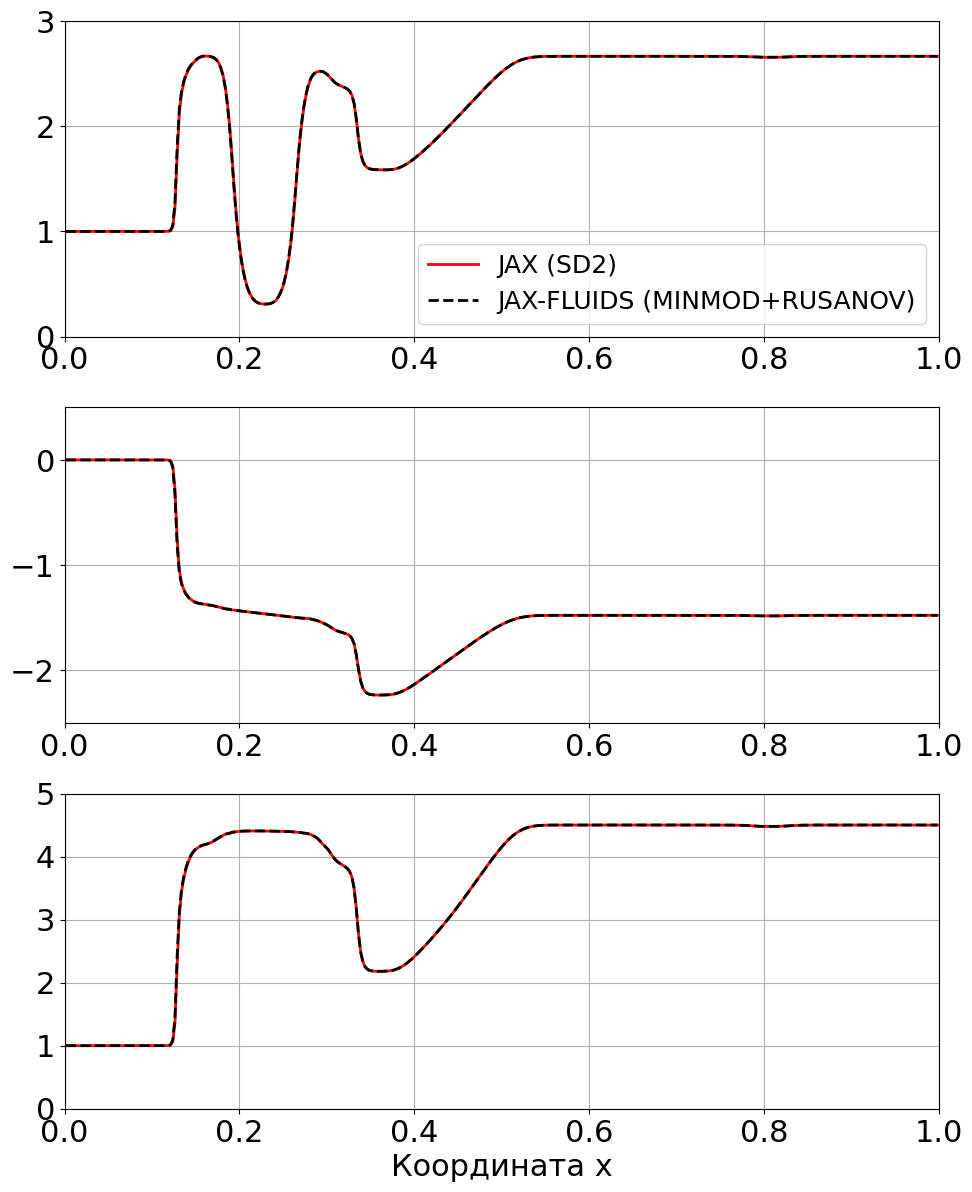

In [9]:
import h5py
import glob
import numpy as np
import matplotlib.pyplot as plt

# Ищем последний файл
h5_files = sorted(glob.glob("./results/**/*.h5", recursive=True))
last_file = h5_files[-1]

with h5py.File(last_file, "r") as f:
    # Используем правильные ключи для JAXFLUIDS
    x_jf = np.array(f["domain/gridX"]).flatten()
    rho_jf = np.array(f["primitives/density"]).flatten()
    u_jf = np.array(f["primitives/velocity"]).flatten()
    p_jf = np.array(f["primitives/pressure"]).flatten()

# Вытаскиваем ваш последний временной слой
rho_my = rho_num[-1]
u_my = u_num[-1]
p_my = p_num[-1]

fig, axes = plt.subplots(3, 1, figsize=(10, 12)) #, sharex=True
fig.tight_layout(pad=3.0)

# График плотности
axes[0].plot(x_num, rho_my, 'r-', lw=2, label='JAX (SD2)')
axes[0].plot(x_jf, rho_jf, 'k--', lw=2, label='JAX-FLUIDS (MINMOD+RUSANOV)')
axes[0].set_xlim(0, 1)
axes[0].set_ylim(0.0, 3.0)
# axes[0].set_ylabel('Density')
axes[0].tick_params(axis='both', labelsize=22)
axes[0].grid(True)
axes[0].legend(prop={'size': 18})

# График скорости
axes[1].plot(x_num, u_my, 'r-', lw=2)
axes[1].plot(x_jf, u_jf, 'k--', lw=2)
axes[1].set_xlim(0, 1)
axes[1].set_ylim(-2.5, 0.5) # Подогнано под масштаб картинки
# axes[1].set_ylabel('Velocity')
axes[1].tick_params(axis='both', labelsize=22)
axes[1].grid(True)

# График давления
axes[2].plot(x_num, p_my, 'r-', lw=2)
axes[2].plot(x_jf, p_jf, 'k--', lw=2)
axes[2].set_xlim(0, 1)
axes[2].set_ylim(0.0, 5.0)  # Подогнано под масштаб картинки
# axes[2].set_ylabel('Pressure')
axes[2].set_xlabel('Координата x', fontsize=22)
axes[2].tick_params(axis='both', labelsize=22)
axes[2].grid(True)

plt.show()

In [10]:
general = {
    "case_name": "modified_sod_shocktube",
    "end_time": 0.25,
    "save_path": "./results",
    "save_dt": 1.0  # <--- БЫЛО 0.05, СТАЛО 1.0
}

domain = {
    "x": {"cells": 16384, "range": [0.0, 1.0]},
    "y": {"cells": 1, "range": [0.0, 1.0]},
    "z": {"cells": 1, "range": [0.0, 1.0]}
}

boundary_conditions = {
    "east": {"type": "ZEROGRADIENT"},
    "west": {"type": "ZEROGRADIENT"},
    "north": {"type": "INACTIVE"},
    "south": {"type": "INACTIVE"},
    "top": {"type": "INACTIVE"},
    "bottom": {"type": "INACTIVE"}
}

initial_condition = {
    "rho": "lambda x: jnp.where(x < 0.3, 1.0, jnp.where(x <= 0.5, 0.1, jnp.where(x < 0.8, 1.0, 2.66666666667)))",
    "u": "lambda x: jnp.where(x < 0.8, 0.0, -1.47901994677)",
    "v": 0.0,
    "w": 0.0,
    "p": "lambda x: jnp.where(x < 0.8, 1.0, 4.5)"
}

material_properties = {
    "equation_of_state": {
        "model": "IdealGas",
        "specific_heat_ratio": 1.4,
        "specific_gas_constant": 1.0
    }
}

output = {
    "primitives": ["density", "velocity", "pressure"]
}

case_setup = {
    "general": general,
    "domain": domain,
    "boundary_conditions": boundary_conditions,
    "initial_condition": initial_condition,
    "material_properties": material_properties,
    "output": output
}

numerical_setup = {
    "active_physics": {
        "is_convective_flux": True,
        "is_viscous_flux": False,
        "is_heat_flux": False,
        "is_volume_force": False
    },
    "conservatives": {
        "halo_cells": 3,
        "time_integration": {
            "integrator": "RK3",
            "CFL": 0.45
        },
        "convective_fluxes": {
            "convective_solver": "GODUNOV",
            "godunov": {
                "riemann_solver": "RUSANOV",
                "signal_speed": "RUSANOV",
                "reconstruction_stencil": "MINMOD",
                "reconstruction_variable": "CONSERVATIVE"
            }
        },
        "positivity": {
            "flux_limiter": None,
            "is_interpolation_limiter": True
        }
    },
    "precision": {
        "is_double_precision_compute": True,
        "is_double_precision_output": True
    },
    "output": {
        "derivative_stencil": "CENTRAL2",
        "logging": {"frequency": 1000000} # <--- БЫЛО 10, СТАЛО 1000000 (отключили логи)
    }
}

print("Конфигурация обновлена для чистого замера скорости!")

with open("case_setup.json", "w") as f:
    json.dump(case_setup, f)
with open("numerical_setup.json", "w") as f:
    json.dump(numerical_setup, f, indent=2)

sys.path.append(os.path.abspath('JAXFLUIDS/src'))

from jaxfluids import InputManager, SimulationManager
from jaxfluids.initialization.initialization_manager import InitializationManager

input_manager = InputManager("case_setup.json", "numerical_setup.json")

print("Инициализация буферов...")
init_manager = InitializationManager(input_manager)
jxf_buffers = init_manager.initialization()
sim_manager = SimulationManager(input_manager)

# ---------------------------------------------------------
# ПРОГРЕВ КОМПИЛЯТОРА (JIT Compilation)
# ---------------------------------------------------------
print("Первый запуск (компиляция JAX + счет)... Пожалуйста, подождите.")
# Копируем буферы, чтобы второй запуск начался с чистого листа
jxf_buffers_warmup = init_manager.initialization()
t_comp_start = time.time()
sim_manager.simulate(jxf_buffers_warmup)
t_comp_end = time.time()
print(f"Время первого запуска (включая компиляцию): {t_comp_end - t_comp_start:.4f} секунд")

# ---------------------------------------------------------
# ЧИСТЫЙ ЗАМЕР СКОРОСТИ СОЛВЕРА
# ---------------------------------------------------------
print("\nВторой запуск (чистый счет без логов и записи файлов)...")
# Инициализируем свежие начальные условия для честного старта при t=0
jxf_buffers_clean = init_manager.initialization()

t_pure_start = time.time()
sim_manager.simulate(jxf_buffers_clean)
t_pure_end = time.time()

pure_time = t_pure_end - t_pure_start
print(f"ЧИСТОЕ ВРЕМЯ РАБОТЫ СОЛВЕРА JAX-FLUIDS: {pure_time:.4f} секунд")

Конфигурация обновлена для чистого замера скорости!
Инициализация буферов...


*------------------------------------------------------------------------------*
*                                                                              *
*                                                                              *
*          _     _    __  __        _____  _      _   _  ___  ____   ____      *
*         | |   / \   \ \/ /       |  ___|| |    | | | ||_ _||  _ \ / ___|     *
*      _  | |  / _ \   \  /  _____ | |_   | |    | | | | | | | | | |\___ \     *
*     | |_| | / ___ \  /  \ |_____||  _|  | |___ | |_| | | | | |_| | ___) |    *
*      \___/ /_/   \_\/_/\_\       |_|    |_____| \___/ |___||____/ |____/     *
*                                                                              *
*                                By BB - ML@AER                                *
*                                                                              *
*------------------------------------------------------------------------------*
* JAX-FLUIDS -              

Первый запуск (компиляция JAX + счет)... Пожалуйста, подождите.


*      \___/ /_/   \_\/_/\_\       |_|    |_____| \___/ |___||____/ |____/     *
*                                                                              *
*                                                                              *
*------------------------------------------------------------------------------*
*                                                                              *
*                           PYTHON Version: 3.12.13                            *
*                              JAX Version: 0.7.2                              *
*                            JAXLIB Version: 0.7.2                             *
*                          JAX-Fluids Version: 0.2.1                           *
*             GIT Commit: 6ce2b03379b41f07a5f12dbd825f57d4b485bd9f             *
*                       DATE & TIME: 2026-05-24 12:14:47                       *
*                               PROCESS ID: 1293                               *
*                           

In [5]:
import jax.numpy as jnp
import numpy as np

# Импортируем классы и функции из вашей библиотеки
from core import Pars1d, Equation1d
from solver import Solver1d, FastSolverWithAllLayersWithoutExtends1d
from boundaries import periodic_bc
from richardson import self_convergence_analysis

def make_smooth_linear_advection():
    """Уравнение линейного переноса: du/dt + a * du/dx = 0 с гладким НУ."""
    a = 1.0  # Скорость адвекции

    def periodic_bc(u, n_ghost):
      return jnp.pad(u, (n_ghost, n_ghost), mode='wrap')

    return Equation1d(
        flux=lambda u: a * u,
        spectral_radius=lambda u: jnp.full_like(u, jnp.abs(a)),
        initial_data=lambda x: jnp.sin(2.0 * jnp.pi * x),  # Бесконечно гладкий синус
        boundary_handler=periodic_bc,
        name="Smooth Linear Advection"
    )

# Инициализируем уравнение
eqn = make_smooth_linear_advection()

In [20]:
def run_convergence_test(J, eqn):
    # Задаем параметры сетки и времени
    pars = Pars1d(
        x_init=0.0,
        x_final=1.0,
        t_final=1,      # Время моделирования (достаточно для сдвига на 1/4 фазы)
        dt_out=0.25,       # Выводим только финальное состояние для экономии памяти
        J=J,               # Количество ячеек (N)
        cfl=0.5,           # Число Куранта
        scheme="fd2"
    )

    # Инициализация решателя.
    # Важно: используем van_leer, так как minmod слишком сильно срезает экстремумы
    # гладкого синуса и может испортить оценку второго порядка.
    #solver = FastSolverWithAllLayersWithoutExtends1d(pars, eqn, limiter_name="minmod", scheme_name="fd2")
    solver = Solver1d(pars, eqn, limiter_name="minmod", scheme_name="fd2")

    # Запуск расчета (возвращается словарь с историей x, t, u_n)
    res = solver.solve()

    # Берем последнее рассчитанное состояние массива u_n
    return res["u_n"][-1]

# Запускаем симуляцию для крупной, средней и мелкой сеток
print("Запуск расчета на крупной сетке (J=100)...")
u_coarse = run_convergence_test(200, eqn)

print("\nЗапуск расчета на средней сетке (J=200)...")
u_medium = run_convergence_test(400, eqn)

print("\nЗапуск расчета на мелкой сетке (J=400)...")
u_fine   = run_convergence_test(800, eqn)

Запуск расчета на крупной сетке (J=100)...
Starting simulation: Smooth Linear Advection
Grid: 200 points, Scheme: fd2/minmod
Simulation finished in 0.3771s
Total steps: 401

Запуск расчета на средней сетке (J=200)...
Starting simulation: Smooth Linear Advection
Grid: 400 points, Scheme: fd2/minmod
Simulation finished in 0.5590s
Total steps: 801

Запуск расчета на мелкой сетке (J=400)...
Starting simulation: Smooth Linear Advection
Grid: 800 points, Scheme: fd2/minmod
Simulation finished in 0.9805s
Total steps: 1601


In [19]:
# Переводим JAX-массивы в обычные Numpy-массивы,
# так как `compute_errors_and_order` использует функции numpy (np.sum, np.max)
u_coarse_np = np.array(u_coarse)
u_medium_np = np.array(u_medium)
u_fine_np   = np.array(u_fine)

# Вызываем анализ самосходимости с коэффициентом измельчения r=2.0
results = self_convergence_analysis(
    u_coarse_np,
    u_medium_np,
    u_fine_np,
    r=2.0,
    var_names=["Гладкая синусоида"]
)

--------------------------------------------------
Анализ самосходимости (Экстраполяция Ричардсона)
Коэффициент измельчения (r) = 2.0
--------------------------------------------------

--- Гладкая синусоида ---
Норма L1:
  Ошибка (Крупная-Средняя): 2.1416e-03
  Ошибка (Средняя-Мелкая):  5.8414e-04
  Наблюдаемый порядок (p):  1.8743
Норма L2:
  Ошибка (Крупная-Средняя): 3.0843e-03
  Ошибка (Средняя-Мелкая):  9.7307e-04
  Наблюдаемый порядок (p):  1.6643
Норма Linf:
  Ошибка (Крупная-Средняя): 8.1011e-03
  Ошибка (Средняя-Мелкая):  3.2672e-03
  Наблюдаемый порядок (p):  1.3101
--------------------------------------------------


In [7]:
from exect_solve_too_task_for_1d_2d import verify_sine_1d, verify_vortex_2d

def make_euler_sine_1d(gamma=1.4):
    def _pressure(q):
        rho = q[..., 0]
        u   = q[..., 1] / rho
        E   = q[..., 2] / rho
        return (gamma - 1.0) * rho * (E - 0.5 * u**2)

    def flux(q):
        rho  = q[..., 0]
        rhou = q[..., 1]
        E    = q[..., 2]
        u    = rhou / rho
        p    = _pressure(q)
        return jnp.stack([rhou, rhou * u + p, u * (E + p)], axis=-1)

    def spectral_radius(q):
      rho = q[..., 0]
      u   = q[..., 1] / rho
      p   = _pressure(q)
      c   = jnp.sqrt(gamma * jnp.maximum(p, 1e-10) / jnp.maximum(rho, 1e-10))
      a   = jnp.abs(u) + c
      return a[..., None]  # ← добавь [..', None] как в make_modified_sod

    def initial_data(x):
        rho = 1.0 + 0.2 * jnp.sin(2.0 * jnp.pi * x)
        u   = jnp.ones_like(x)
        p   = jnp.ones_like(x)
        E   = p / ((gamma - 1.0) * rho) + 0.5 * u**2
        return jnp.stack([rho, rho * u, rho * E], axis=-1)  # (J, 3)

    return Equation1d(
        flux=flux,
        spectral_radius=spectral_radius,
        initial_data=initial_data,
        boundary_handler=periodic_bc,
        name="Euler 1D (Smooth Sine)"
    )

verify_sine_1d(make_euler_sine_1d(), scheme_name="fd2", cfl=0.475, grids=[400, 800, 1600, 3200])

ВЕРИФИКАЦИЯ 1D: ГЛАДКИЙ СИНУС  (схема: fd2)
  J=  400 готово

  rho:
         N |          L1   p_L1 |          L2   p_L2
  ------------------------------------------------
       400 |  1.3678e-04    --- |  2.5424e-04    ---

  u:
         N |          L1   p_L1 |          L2   p_L2
  ------------------------------------------------
       400 |  1.4611e-15    --- |  1.8373e-15    ---

  p:
         N |          L1   p_L1 |          L2   p_L2
  ------------------------------------------------
       400 |  1.7905e-15    --- |  2.2692e-15    ---
  J=  800 готово

  rho:
         N |          L1   p_L1 |          L2   p_L2
  ------------------------------------------------
       400 |  1.3678e-04    --- |  2.5424e-04    ---
       800 |  5.1286e-04  -1.91 |  5.5929e-04  -1.14

  u:
         N |          L1   p_L1 |          L2   p_L2
  ------------------------------------------------
       400 |  1.4611e-15    --- |  1.8373e-15    ---
       800 |  1.8677e-15  -0.35 |  2.3309e-15  -0.

[(400,
  [(np.float64(0.00013678307693738316), np.float64(0.0002542417450788951)),
   (np.float64(1.461053500406706e-15), np.float64(1.837293320895035e-15)),
   (np.float64(1.7905121829642214e-15), np.float64(2.2691706600506283e-15))]),
 (800,
  [(np.float64(0.0005128604450140949), np.float64(0.0005592926182072572)),
   (np.float64(1.8676726831756698e-15), np.float64(2.330860293145086e-15)),
   (np.float64(1.9963197761541095e-15), np.float64(2.4863698085298597e-15))]),
 (1600,
  [(np.float64(0.00025344842278525714), np.float64(0.0002783789961025782)),
   (np.float64(2.563713130676604e-15), np.float64(3.1669671262621222e-15)),
   (np.float64(2.9821284330822094e-15), np.float64(3.766310932691826e-15))]),
 (3200,
  [(np.float64(2.4677311805013784e-06), np.float64(8.093466376135441e-06)),
   (np.float64(3.169964291060978e-15), np.float64(3.976448046457022e-15)),
   (np.float64(3.8624659026709195e-15), np.float64(4.873076850657082e-15))])]